# Lab 17: Histograms - Data Visualization
## IBM Data Analytics Capstone Project 
### Objective: Visualize distributions, relationships, composition and comparisons using histograms

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import numpy as np

# Load dataset and create SQLite DB
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv')
conn = sqlite3.connect('survey-data.sqlite')
df.to_sql('main', conn, if_exists='replace', index=False)

print("Dataset loaded and SQLite DB created!")
print("Shape:", df.shape)

Dataset loaded and SQLite DB created!
Shape: (65437, 114)


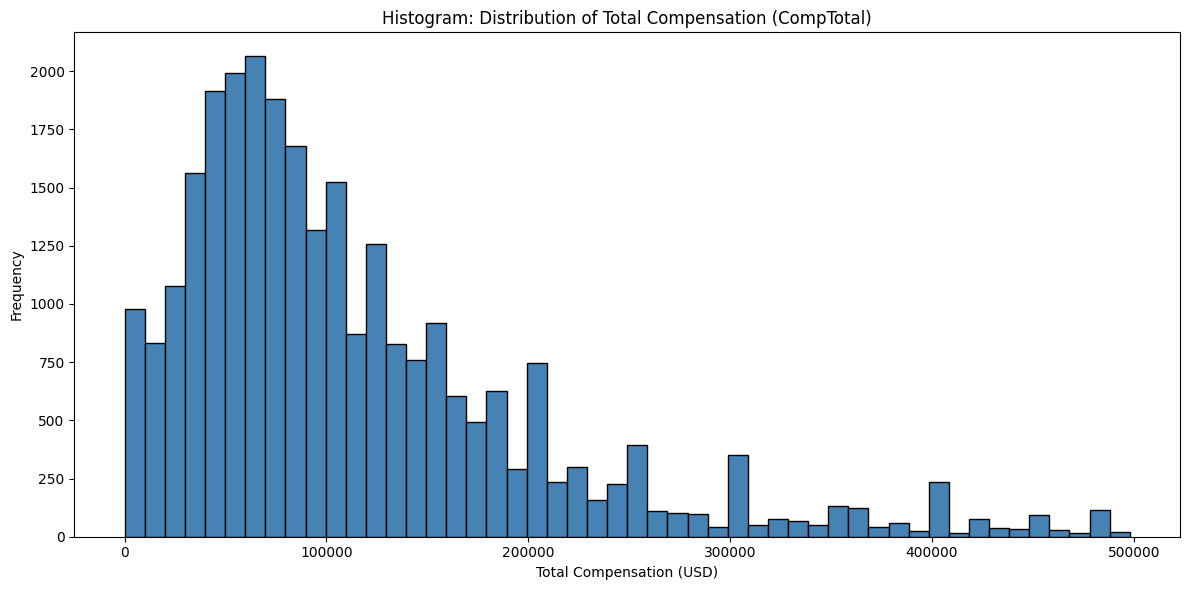

CompTotal histogram saved!


In [2]:
QUERY = """SELECT CompTotal FROM main 
WHERE CompTotal IS NOT NULL AND CompTotal < 500000"""
df_comp = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(12, 6))
plt.hist(df_comp['CompTotal'], bins=50, color='steelblue', edgecolor='black')
plt.title('Histogram: Distribution of Total Compensation (CompTotal)')
plt.xlabel('Total Compensation (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('hist_comptotal.png', dpi=150, bbox_inches='tight')
plt.show()
print("CompTotal histogram saved!")

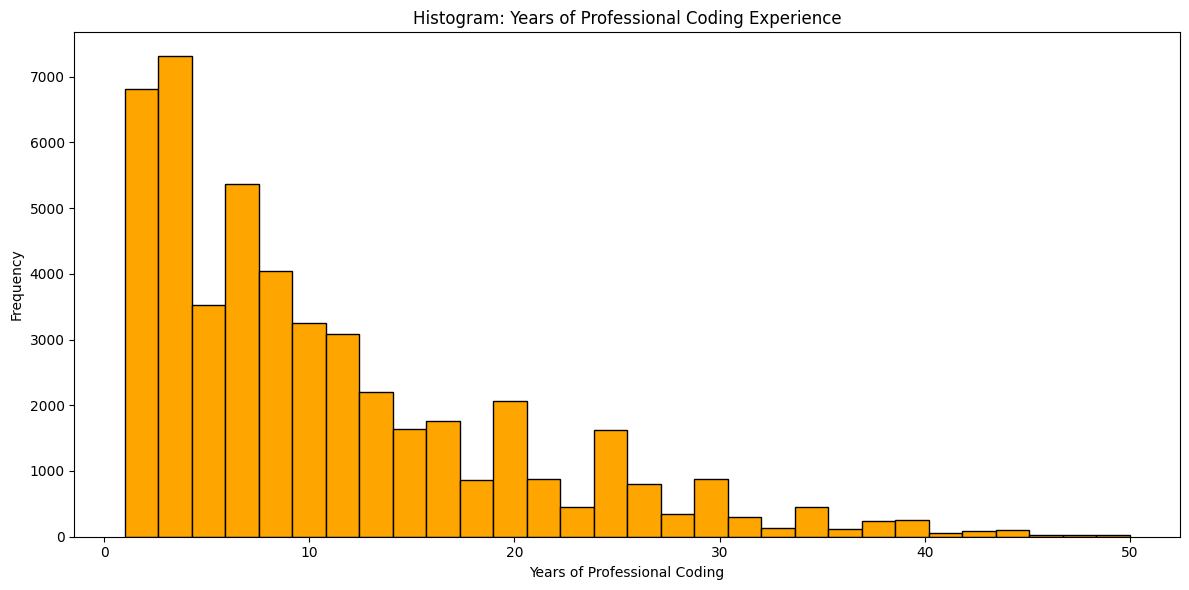

YearsCodePro histogram saved!


In [3]:
QUERY = """SELECT CAST(YearsCodePro AS FLOAT) as YearsCodePro 
FROM main WHERE YearsCodePro NOT IN ('Less than 1 year', 'More than 50 years')
AND YearsCodePro IS NOT NULL"""
df_years = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(12, 6))
plt.hist(df_years['YearsCodePro'].dropna(), bins=30, 
         color='orange', edgecolor='black')
plt.title('Histogram: Years of Professional Coding Experience')
plt.xlabel('Years of Professional Coding')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('hist_yearscodepro.png', dpi=150, bbox_inches='tight')
plt.show()
print("YearsCodePro histogram saved!")

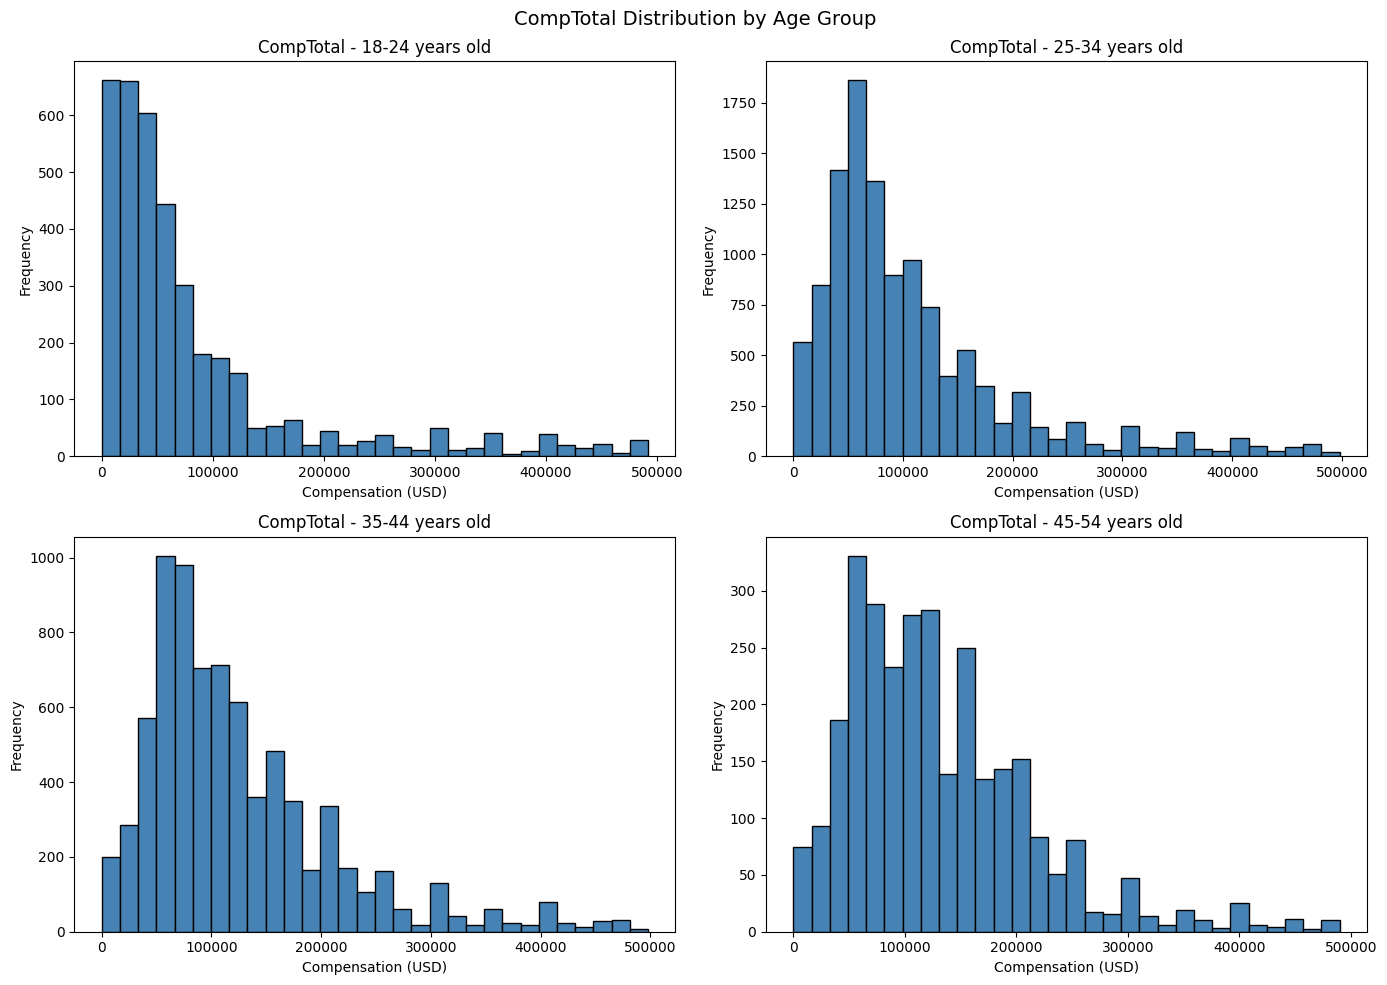

CompTotal by age group saved!


In [4]:
# Query CompTotal for different age groups
age_groups = ['18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, age in enumerate(age_groups):
    QUERY = f"""
    SELECT CompTotal FROM main 
    WHERE Age = '{age}' 
    AND CompTotal IS NOT NULL 
    AND CompTotal < 500000
    """
    df_age = pd.read_sql_query(QUERY, conn)
    axes[i].hist(df_age['CompTotal'], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'CompTotal - {age}')
    axes[i].set_xlabel('Compensation (USD)')
    axes[i].set_ylabel('Frequency')

plt.suptitle('CompTotal Distribution by Age Group', fontsize=14)
plt.tight_layout()
plt.savefig('hist_comp_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("CompTotal by age group saved!")

In [6]:
# Check TimeSearching column
QUERY = "SELECT TimeSearching, COUNT(*) as count FROM main WHERE TimeSearching IS NOT NULL GROUP BY TimeSearching LIMIT 10"
print(pd.read_sql_query(QUERY, conn))

                TimeSearching  count
0         15-30 minutes a day   7805
1         30-60 minutes a day  10951
2        60-120 minutes a day   5275
3  Less than 15 minutes a day   2689
4      Over 120 minutes a day   2191


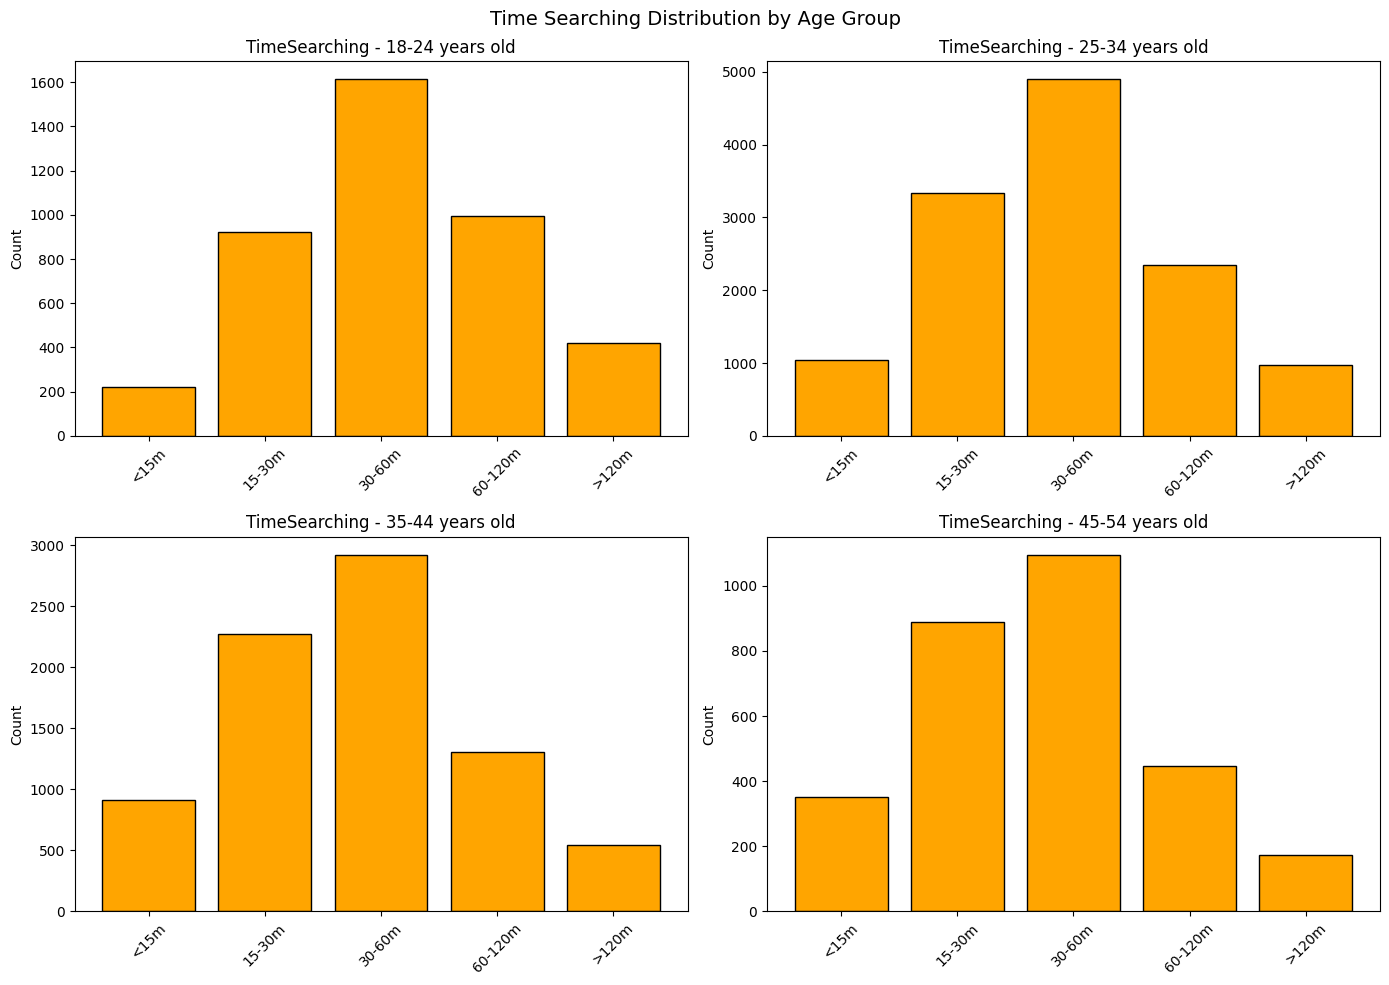

TimeSearching by age group saved!


In [7]:
# TimeSearching is categorical, use bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Define correct order
time_order = ['Less than 15 minutes a day', '15-30 minutes a day', 
              '30-60 minutes a day', '60-120 minutes a day', 'Over 120 minutes a day']

for i, age in enumerate(age_groups):
    QUERY = f"""
    SELECT TimeSearching, COUNT(*) as count FROM main 
    WHERE Age = '{age}' 
    AND TimeSearching IS NOT NULL
    GROUP BY TimeSearching
    """
    df_time = pd.read_sql_query(QUERY, conn)
    df_time = df_time.set_index('TimeSearching').reindex(time_order).fillna(0)
    
    axes[i].bar(range(len(df_time)), df_time['count'], color='orange', edgecolor='black')
    axes[i].set_title(f'TimeSearching - {age}')
    axes[i].set_xticks(range(len(df_time)))
    axes[i].set_xticklabels(['<15m', '15-30m', '30-60m', '60-120m', '>120m'], rotation=45)
    axes[i].set_ylabel('Count')

plt.suptitle('Time Searching Distribution by Age Group', fontsize=14)
plt.tight_layout()
plt.savefig('hist_timesearching_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("TimeSearching by age group saved!")

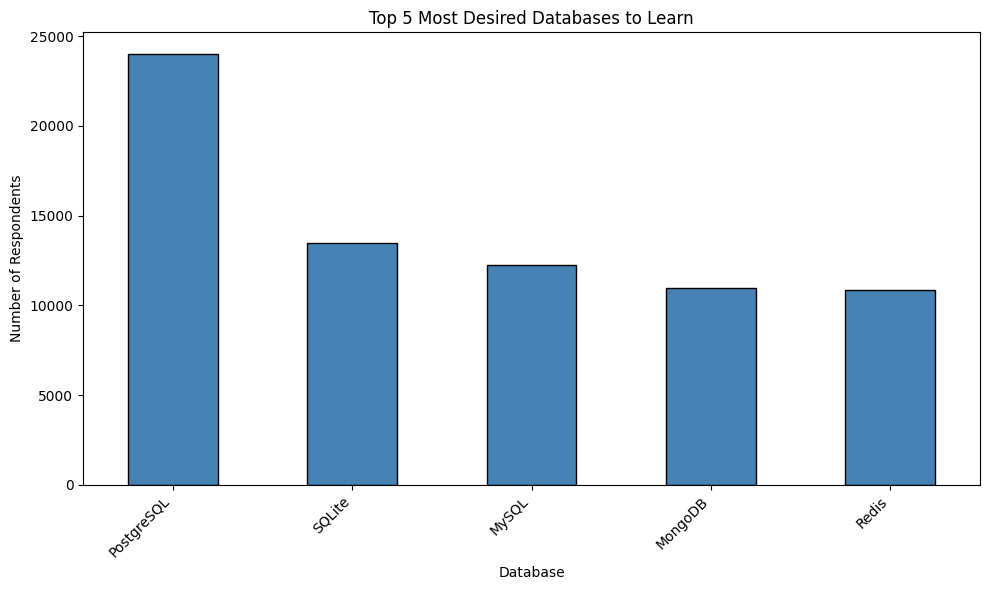

Top 5 databases histogram saved!


In [8]:
# Top 5 desired databases
QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df_db = pd.read_sql_query(QUERY, conn)
db_series = df_db['DatabaseWantToWorkWith'].str.split(';').explode()
top5_db = db_series.value_counts().head(5)

plt.figure(figsize=(10, 6))
top5_db.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 5 Most Desired Databases to Learn')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hist_top5_databases.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top 5 databases histogram saved!")

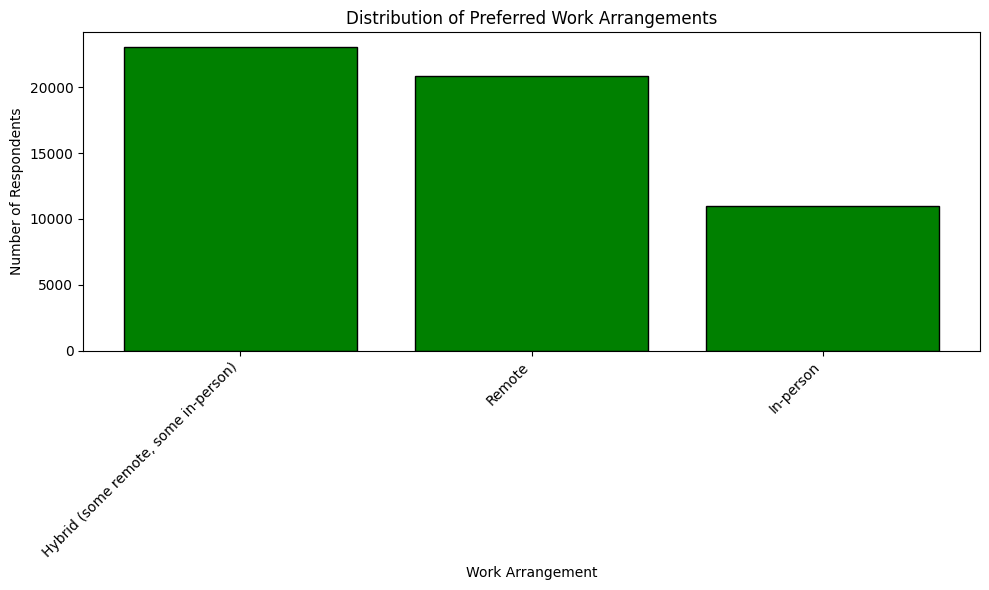

RemoteWork histogram saved!


In [9]:
# Remote work distribution
QUERY = """
SELECT RemoteWork, COUNT(*) as count FROM main 
WHERE RemoteWork IS NOT NULL 
GROUP BY RemoteWork
ORDER BY count DESC
"""
df_remote = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 6))
plt.bar(df_remote['RemoteWork'], df_remote['count'], 
        color='green', edgecolor='black')
plt.title('Distribution of Preferred Work Arrangements')
plt.xlabel('Work Arrangement')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hist_remotework.png', dpi=150, bbox_inches='tight')
plt.show()
print("RemoteWork histogram saved!")

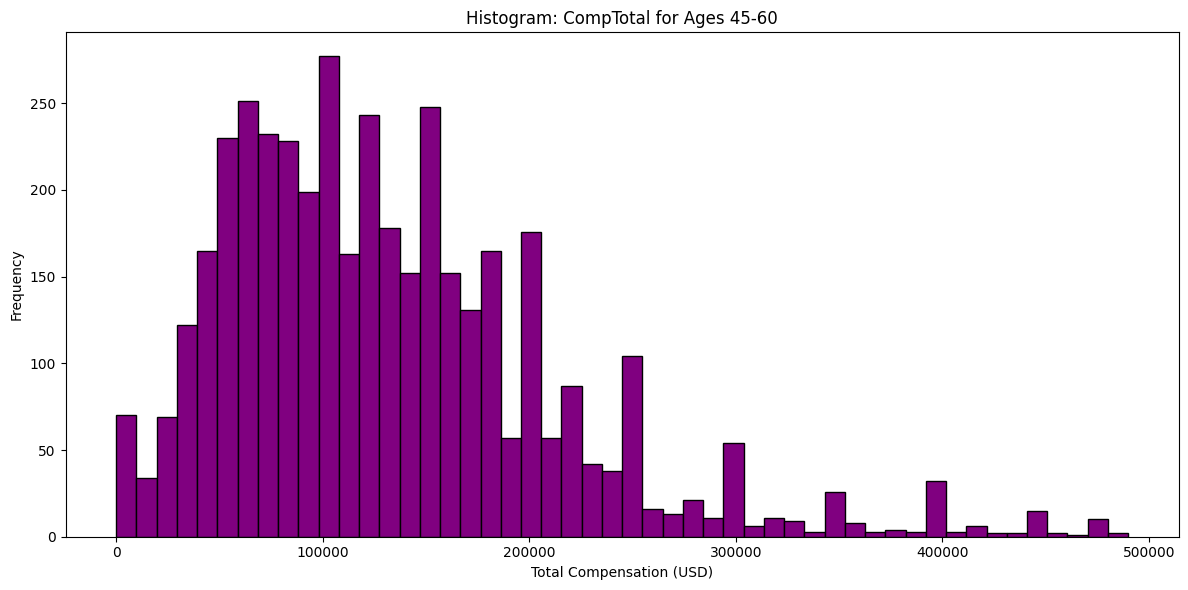

CompTotal 45-60 histogram saved!


In [10]:
# CompTotal for ages 45-60
QUERY = """
SELECT CompTotal FROM main
WHERE Age IN ('45-54 years old', '55-64 years old')
AND CompTotal IS NOT NULL
AND CompTotal < 500000
"""
df_comp_age = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(12, 6))
plt.hist(df_comp_age['CompTotal'], bins=50, color='purple', edgecolor='black')
plt.title('Histogram: CompTotal for Ages 45-60')
plt.xlabel('Total Compensation (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('hist_comp_45_60.png', dpi=150, bbox_inches='tight')
plt.show()
print("CompTotal 45-60 histogram saved!")

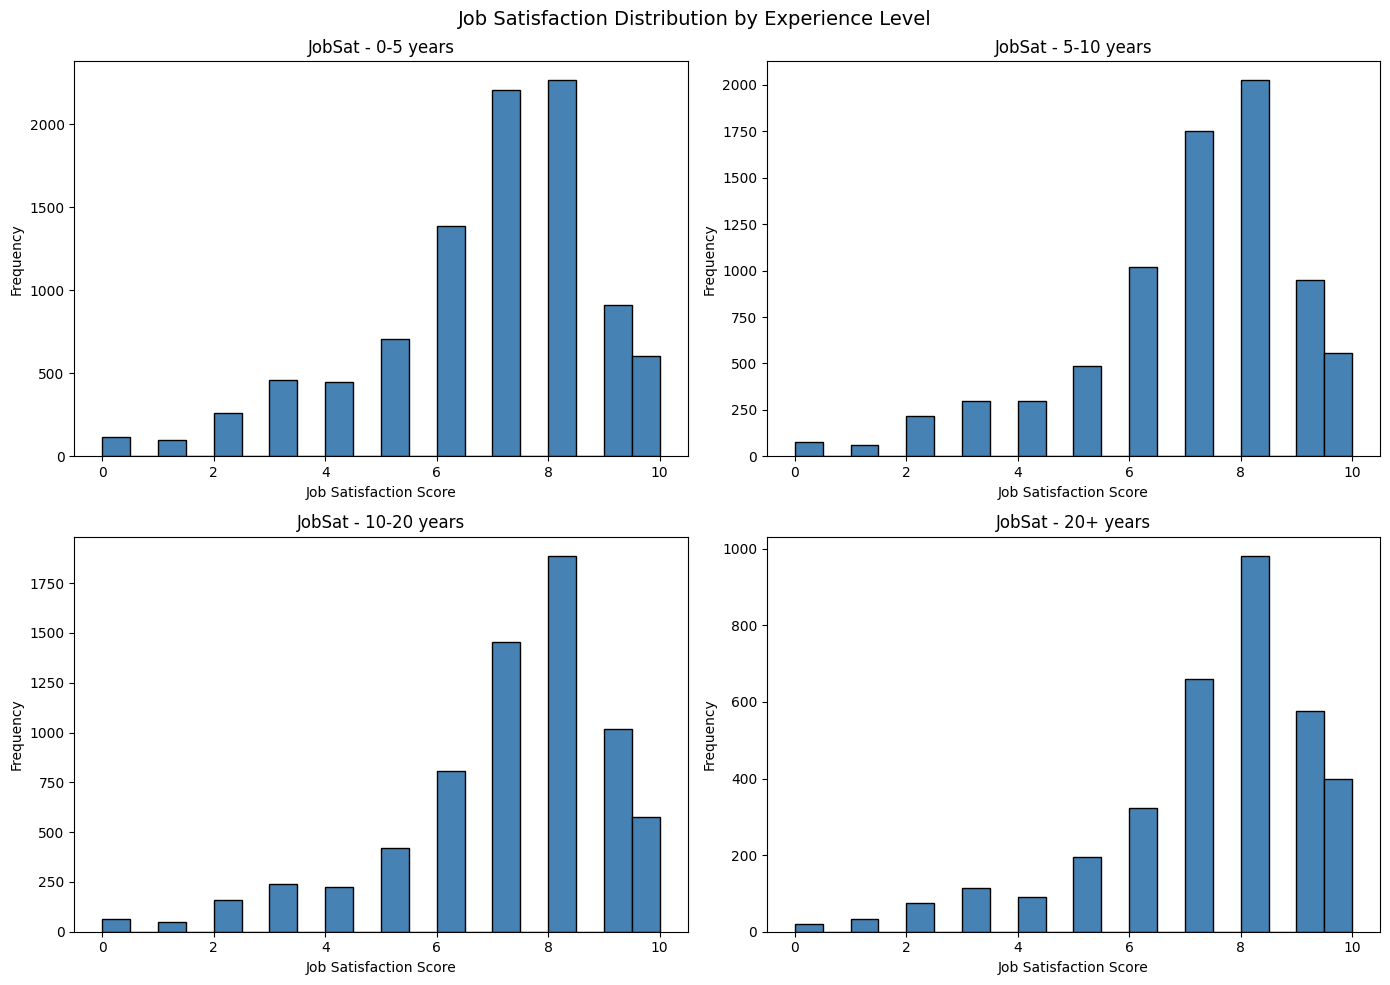

JobSat histograms saved!
Database connection closed!


In [11]:
# JobSat distribution by experience level
QUERY = """
SELECT JobSat,
CASE 
    WHEN CAST(YearsCodePro AS INTEGER) <= 5 THEN '0-5 years'
    WHEN CAST(YearsCodePro AS INTEGER) <= 10 THEN '5-10 years'
    WHEN CAST(YearsCodePro AS INTEGER) <= 20 THEN '10-20 years'
    ELSE '20+ years'
END as ExperienceRange
FROM main
WHERE JobSat IS NOT NULL 
AND YearsCodePro IS NOT NULL
AND YearsCodePro NOT LIKE '%Less%'
AND YearsCodePro NOT LIKE '%More%'
"""
df_jobsat = pd.read_sql_query(QUERY, conn)

exp_groups = ['0-5 years', '5-10 years', '10-20 years', '20+ years']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, exp in enumerate(exp_groups):
    data = df_jobsat[df_jobsat['ExperienceRange'] == exp]['JobSat']
    axes[i].hist(data, bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(f'JobSat - {exp}')
    axes[i].set_xlabel('Job Satisfaction Score')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Job Satisfaction Distribution by Experience Level', fontsize=14)
plt.tight_layout()
plt.savefig('hist_jobsat_experience.png', dpi=150, bbox_inches='tight')
plt.show()

conn.close()
print("JobSat histograms saved!")
print("Database connection closed!")